# QLoRA Fine-Tuning — SDXL on Naruto (Standalone)

Self-contained: own caching, own config, doesn't depend on any other notebook's session
state. Screens 2 QLoRA configs briefly, fully trains the winner on the complete dataset.

**Dtype fix included from the start:** LoRA adapter parameters are explicitly cast to fp16
to match the 4-bit base's compute dtype. PEFT can default-initialize new LoRA layers in
fp32 regardless of the quantized base's dtype -- if left uncorrected, this produces a
`Query`/`Key`/`Value` dtype mismatch inside attention (`query.dtype: torch.float32` vs.
`key/value.dtype: torch.float16`), which both SDPA and xformers reject. A sanity-check print
confirms the cast took effect before training starts, so if something's still wrong you see
it immediately rather than after a full run.

In [1]:
!pip install -q -U pip setuptools wheel
!pip install -q -U "diffusers>=0.31.0" "transformers>=4.44" "accelerate>=0.34" \
    "peft>=0.13" "bitsandbytes>=0.43" "datasets>=2.21" "safetensors>=0.4.5" \
    "huggingface_hub>=0.24" "torchao>=0.16.0" pandas
!pip install -q -U xformers || echo "xformers install failed -- continuing without it, SDPA (diffusers' default attention) gives equivalent performance."


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 47.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cu128 requires setuptools<82, but you have setuptools 84.0.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is in

In [2]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import gc, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

from datasets import load_dataset
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionXLPipeline
from transformers import CLIPTextModel, CLIPTextModelWithProjection, CLIPTokenizer
from peft import LoraConfig, get_peft_model_state_dict
import bitsandbytes as bnb
from diffusers.optimization import get_scheduler

try:
    from diffusers import BitsAndBytesConfig
except ImportError:
    from transformers import BitsAndBytesConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
assert device == "cuda", "Run this on a Colab GPU runtime."
weight_dtype = torch.float16
print("device:", device, "|", torch.cuda.get_device_name(0))

def slug(name):
    return name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "").replace(",", "")


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


device: cuda | Tesla T4


## Config

In [3]:
class CFG:
    base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
    vae_id        = "madebyollin/sdxl-vae-fp16-fix"
    dataset_id    = "lambdalabs/naruto-blip-captions"

    resolution = 1024
    val_fraction = 0.15

    train_batch_size            = 1
    gradient_accumulation_steps = 8

    n_screen_steps       = 100
    screen_subset_size   = 200
    screen_eval_every     = 20

    n_full_steps      = 600
    full_eval_every    = 50

    lr_warmup_steps = 20
    seed = 42
    screen_output_root = "qlora_screening_runs"
    full_output_root    = "qlora_full_runs"

cfg = CFG()
torch.manual_seed(cfg.seed); random.seed(cfg.seed)
os.makedirs(cfg.screen_output_root, exist_ok=True)
os.makedirs(cfg.full_output_root, exist_ok=True)

TARGET_MODULES = ["to_q", "to_k", "to_v", "to_out.0"]


## 1. Precompute-then-free: cache the dataset once

VAE and both text encoders are frozen and only used here, once. After this cell they're
deleted and their VRAM reclaimed -- training only ever loads the (4-bit quantized) UNet.

In [4]:
tokenizer_one = CLIPTokenizer.from_pretrained(cfg.base_model_id, subfolder="tokenizer")
tokenizer_two = CLIPTokenizer.from_pretrained(cfg.base_model_id, subfolder="tokenizer_2")
text_encoder_one = CLIPTextModel.from_pretrained(cfg.base_model_id, subfolder="text_encoder", torch_dtype=weight_dtype).to(device)
text_encoder_two = CLIPTextModelWithProjection.from_pretrained(cfg.base_model_id, subfolder="text_encoder_2", torch_dtype=weight_dtype).to(device)
vae = AutoencoderKL.from_pretrained(cfg.vae_id, torch_dtype=torch.float32).to(device)
vae.enable_tiling()
for m in (text_encoder_one, text_encoder_two, vae):
    m.requires_grad_(False)
    m.eval()

train_transforms = transforms.Compose([
    transforms.Resize(cfg.resolution, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(cfg.resolution),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

@torch.no_grad()
def encode_prompt(caption):
    embeds_list, pooled = [], None
    for tok, enc in [(tokenizer_one, text_encoder_one), (tokenizer_two, text_encoder_two)]:
        ti = tok(caption, padding="max_length", max_length=tok.model_max_length, truncation=True, return_tensors="pt").to(device)
        out = enc(ti.input_ids, output_hidden_states=True)
        embeds_list.append(out.hidden_states[-2])
        if enc is text_encoder_two:
            pooled = out[0]
    return torch.cat(embeds_list, dim=-1).squeeze(0).cpu(), pooled.squeeze(0).cpu()

@torch.no_grad()
def encode_image(image):
    pv = train_transforms(image.convert("RGB")).unsqueeze(0).to(device, dtype=torch.float32)
    return (vae.encode(pv).latent_dist.sample() * vae.config.scaling_factor).squeeze(0).cpu()

full_dataset = load_dataset(cfg.dataset_id, split="train")
split = full_dataset.train_test_split(test_size=cfg.val_fraction, seed=cfg.seed)
train_examples, val_examples = split["train"], split["test"]
print(f"{len(train_examples)} train examples, {len(val_examples)} held-out validation examples.")

def build_cache(examples, label):
    cached = []
    for i, ex in enumerate(examples):
        latents = encode_image(ex["image"])
        pe, pooled = encode_prompt(ex["text"])
        cached.append({"latents": latents, "prompt_embeds": pe, "pooled_embeds": pooled})
        if (i + 1) % 200 == 0:
            print(f"  cached {i+1}/{len(examples)} {label} examples...")
    print(f"Cached {len(cached)} {label} examples.")
    return cached

train_cache = build_cache(train_examples, "train")
val_cache   = build_cache(val_examples, "validation")

del vae, text_encoder_one, text_encoder_two
gc.collect(); torch.cuda.empty_cache()
print("VAE + text encoders freed from VRAM.")


tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

...

data/train-00000-of-00002-12944970063701(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-cefa2f480689f1(…): reconstructing file:   0%|          |  0.00B /  357MB            

data/train-00001-of-00002-cefa2f480689f1(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

1037 train examples, 184 held-out validation examples.
  cached 200/1037 train examples...
  cached 400/1037 train examples...
  cached 600/1037 train examples...
  cached 800/1037 train examples...
  cached 1000/1037 train examples...
Cached 1037 train examples.
Cached 184 validation examples.
VAE + text encoders freed from VRAM.


In [5]:
class CachedLatentsDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(examples):
    return {
        "latents": torch.stack([e["latents"] for e in examples]),
        "prompt_embeds": torch.stack([e["prompt_embeds"] for e in examples]),
        "pooled_embeds": torch.stack([e["pooled_embeds"] for e in examples]),
    }

def make_dataloader(cached_list, shuffle):
    return DataLoader(CachedLatentsDataset(cached_list), batch_size=cfg.train_batch_size,
                       shuffle=shuffle, collate_fn=collate_fn)

screen_train_dataloader = make_dataloader(train_cache[:cfg.screen_subset_size], shuffle=True)
full_train_dataloader   = make_dataloader(train_cache, shuffle=True)
val_dataloader          = make_dataloader(val_cache, shuffle=False)

def cycle(dl):
    while True:
        for b in dl:
            yield b

noise_scheduler = DDPMScheduler.from_pretrained(cfg.base_model_id, subfolder="scheduler")

def get_add_time_ids(res, dtype, bsz):
    return torch.tensor([[res, res, 0, 0, res, res]], dtype=dtype).repeat(bsz, 1).to(device)

@torch.no_grad()
def compute_validation_loss(unet):
    unet.eval()
    losses = []
    for batch in val_dataloader:
        latents = batch["latents"].to(device, dtype=torch.float32)
        prompt_embeds = batch["prompt_embeds"].to(device, dtype=weight_dtype)
        pooled_embeds = batch["pooled_embeds"].to(device, dtype=weight_dtype)
        bsz = latents.shape[0]
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps).to(weight_dtype)
        add_time_ids = get_add_time_ids(cfg.resolution, weight_dtype, bsz)
        added_cond_kwargs = {"text_embeds": pooled_embeds, "time_ids": add_time_ids}
        with torch.amp.autocast("cuda"):
            pred = unet(noisy_latents, timesteps, encoder_hidden_states=prompt_embeds,
                        added_cond_kwargs=added_cond_kwargs).sample
            loss = F.mse_loss(pred.float(), noise.float())
        losses.append(loss.item())
    unet.train()
    return sum(losses) / len(losses)


scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

## 2. QLoRA train function

4-bit NF4 base + LoRA on top, fp16 everywhere, 8-bit AdamW, gradient checkpointing,
xformers/SDPA attention, batch size 1 + gradient accumulation.

In [12]:
import os
import gc
import time
import torch
import torch.nn.functional as F
from diffusers import UNet2DConditionModel, StableDiffusionXLPipeline
from diffusers.optimization import get_scheduler
from transformers import BitsAndBytesConfig
import bitsandbytes as bnb
from peft import LoraConfig, get_peft_model_state_dict

def train_qlora(run_cfg, dataloader, n_steps, eval_every, output_root):
    print(f"\n=== {run_cfg['name']} ({n_steps} steps) ===")
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=weight_dtype, bnb_4bit_use_double_quant=True,
    )
    unet = UNet2DConditionModel.from_pretrained(
        cfg.base_model_id, subfolder="unet",
        quantization_config=bnb_config, torch_dtype=weight_dtype, device_map={"": 0},
    )
    unet.requires_grad_(False)
    unet.enable_gradient_checkpointing()

    lora_config = LoraConfig(
        r=run_cfg["rank"], lora_alpha=run_cfg["alpha"], lora_dropout=0.0,
        target_modules=TARGET_MODULES, use_dora=False,
    )
    unet.add_adapter(lora_config)

    # Force all LoRA parameters to explicitly match the compute dtype
    for n, p in unet.named_parameters():
        if "lora" in n:
            p.data = p.data.to(weight_dtype)
            p.requires_grad_(True)

    # Attention Block Hook to enforce dtype uniform conversion before xFormers processing
    from diffusers.models.attention_processor import Attention
    def cast_to_weight_dtype(module, input, output):
        if isinstance(output, torch.Tensor):
            return output.to(weight_dtype)
        elif isinstance(output, tuple):
            return tuple(x.to(weight_dtype) if isinstance(x, torch.Tensor) else x for x in output)
        return output

    for name, module in unet.named_modules():
        if isinstance(module, Attention):
            if hasattr(module, "to_q"):
                module.to_q.register_forward_hook(cast_to_weight_dtype)
            if hasattr(module, "to_k"):
                module.to_k.register_forward_hook(cast_to_weight_dtype)
            if hasattr(module, "to_v"):
                module.to_v.register_forward_hook(cast_to_weight_dtype)

    for n, p in unet.named_parameters():
        if "lora" in n:
            print(f"  sanity check: {n} dtype = {p.dtype} (should be {weight_dtype})")
            break

    trainable_params = [p for p in unet.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable_params)
    print(f"  trainable params: {n_trainable:,}")

    try:
        unet.enable_xformers_memory_efficient_attention()
    except Exception as e:
        print(f"  xformers unavailable ({e}); continuing with default SDPA attention.")

    optimizer = bnb.optim.AdamW8bit(trainable_params, lr=run_cfg["lr"], weight_decay=1e-2)
    lr_scheduler = get_scheduler("constant_with_warmup", optimizer=optimizer,
                                  num_warmup_steps=min(cfg.lr_warmup_steps, n_steps // 4),
                                  num_training_steps=n_steps)
    scaler = None

    unet.train()
    train_losses, val_steps, val_losses = [], [], []
    data_iter = cycle(dataloader)
    t0 = time.time()

    for step in range(n_steps):
        batch = next(data_iter)
        latents = batch["latents"].to(device, dtype=weight_dtype)
        prompt_embeds = batch["prompt_embeds"].to(device, dtype=weight_dtype)
        pooled_embeds = batch["pooled_embeds"].to(device, dtype=weight_dtype)

        # FIX: Explicitly extracted the integer index dimension [0]
        bsz = latents.shape[0]

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps).to(weight_dtype)
        add_time_ids = get_add_time_ids(cfg.resolution, weight_dtype, bsz)
        added_cond_kwargs = {"text_embeds": pooled_embeds, "time_ids": add_time_ids}

        pred = unet(noisy_latents, timesteps, encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs=added_cond_kwargs).sample

        loss = F.mse_loss(pred.float(), noise.float())
        loss_scaled = loss / cfg.gradient_accumulation_steps

        loss_scaled.backward()
        if (step + 1) % cfg.gradient_accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        train_losses.append(loss.item())

        if (step + 1) % eval_every == 0 or step == n_steps - 1:
            val_loss = compute_validation_loss(unet)
            val_steps.append(step + 1)
            val_losses.append(val_loss)
            print(f"  step {step+1}/{n_steps} | train {loss.item():.4f} | val {val_loss:.4f}")

    elapsed = time.time() - t0
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

    save_path = os.path.join(output_root, slug(run_cfg["name"]))
    os.makedirs(save_path, exist_ok=True)
    state_dict = get_peft_model_state_dict(unet)
    StableDiffusionXLPipeline.save_lora_weights(save_path, unet_lora_layers=state_dict)

    result = dict(
        name=run_cfg["name"], adapter="qlora", rank=run_cfg["rank"], alpha=run_cfg["alpha"],
        lr=run_cfg["lr"], n_trainable=n_trainable, peak_mem_gb=peak_mem_gb, elapsed_s=elapsed,
        train_losses=train_losses, val_steps=val_steps, val_losses=val_losses,
        final_train_loss=sum(train_losses[-min(20, len(train_losses)):]) / min(20, len(train_losses)),
        final_val_loss=val_losses[-1], save_path=save_path,
    )
    print(f"  done: {n_trainable:,} params | peak {peak_mem_gb:.2f}GB | {elapsed:.0f}s | "
          f"final train {result['final_train_loss']:.4f} | final val {result['final_val_loss']:.4f}")

    del unet, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return result


---
## 3. Screening — 2 QLoRA configs, short runs

If either config still throws the dtype error even with the fix above, the sanity-check
print right before training will show you the actual dtype so it's obvious whether the cast
took effect or the problem is elsewhere.

In [13]:
QLORA_SCREEN_CONFIGS = [
    dict(name="QLoRA A (r=8, α=16)",  rank=8,  alpha=16, lr=1e-4),
    dict(name="QLoRA B (r=16, α=32)", rank=16, alpha=32, lr=1e-4),
]

screening_results = []
for qc in QLORA_SCREEN_CONFIGS:
    try:
        screening_results.append(train_qlora(
            qc, screen_train_dataloader, cfg.n_screen_steps, cfg.screen_eval_every, cfg.screen_output_root
        ))
    except Exception as e:
        print(f"  FAILED ({qc['name']}): {e}")
        gc.collect(); torch.cuda.empty_cache()

screening_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("train_losses", "val_steps", "val_losses")}
    for r in screening_results
])
screening_df.to_csv("qlora_screening_results.csv", index=False)
screening_df



=== QLoRA A (r=8, α=16) (100 steps) ===
  sanity check: down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_q.lora_A.default.weight dtype = torch.float16 (should be torch.float16)
  trainable params: 11,612,160
  step 20/100 | train 0.1452 | val 0.0888
  step 40/100 | train 0.3324 | val 0.0854
  step 60/100 | train 0.0283 | val 0.0880
  step 80/100 | train 0.1892 | val 0.0883
  step 100/100 | train 0.2270 | val 0.0892
  done: 11,612,160 params | peak 2.82GB | 838s | final train 0.0844 | final val 0.0892

=== QLoRA B (r=16, α=32) (100 steps) ===
  sanity check: down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_q.lora_A.default.weight dtype = torch.float16 (should be torch.float16)
  trainable params: 23,224,320
  step 20/100 | train 0.1319 | val 0.0844
  step 40/100 | train 0.0316 | val 0.0889
  step 60/100 | train 0.0314 | val 0.0898
  step 80/100 | train 0.1744 | val 0.0897
  step 100/100 | train 0.0212 | val 0.0892
  done: 23,224,320 params | peak 2.89GB | 839s | final t

,name,adapter,rank,alpha,lr,n_trainable,peak_mem_gb,elapsed_s,final_train_loss,final_val_loss,save_path
0,"QLoRA A (r=8, α=16)",qlora,8,16,0.0001,11612160,2.823314,837.653601,0.084430,0.089182,qlora_screening_runs/QLoRA_A_r8_α16
1,"QLoRA B (r=16, α=32)",qlora,16,32,0.0001,23224320,2.892987,838.873751,0.089241,0.089159,qlora_screening_runs/QLoRA_B_r16_α32


### Pick the winner

In [14]:
assert len(screening_df) > 0, "Both QLoRA configs failed screening -- check the error above before continuing."
winner_name = screening_df.loc[screening_df["final_val_loss"].idxmin(), "name"]
winner_cfg = next(qc for qc in QLORA_SCREEN_CONFIGS if qc["name"] == winner_name)
print(f"QLoRA winner: {winner_name} (val loss {screening_df['final_val_loss'].min():.4f})")


QLoRA winner: QLoRA B (r=16, α=32) (val loss 0.0892)


---
## 4. Full training — the winner, on the full dataset, 600 steps


=== QLoRA B (r=16, α=32) (600 steps) ===


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  sanity check: down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_q.lora_A.default.weight dtype = torch.float16 (should be torch.float16)
  trainable params: 23,224,320
  step 50/600 | train 0.1207 | val 0.0804
  step 100/600 | train 0.0032 | val 0.0847
  step 150/600 | train 0.0032 | val 0.0880
  step 200/600 | train 0.0263 | val 0.0938
  step 250/600 | train 0.0821 | val 0.0797
  step 300/600 | train 0.0278 | val 0.0879
  step 350/600 | train 0.0030 | val 0.0847
  step 400/600 | train 0.0338 | val 0.0876
  step 450/600 | train 0.0158 | val 0.0878
  step 500/600 | train 0.1118 | val 0.0802
  step 550/600 | train 0.2581 | val 0.0841
  step 600/600 | train 0.1210 | val 0.0768
  done: 23,224,320 params | peak 2.89GB | 2748s | final train 0.0683 | final val 0.0768

QLoRA best checkpoint: QLoRA B (r=16, α=32) (val loss 0.0768)
Weights saved to: qlora_full_runs/QLoRA_B_r16_α32


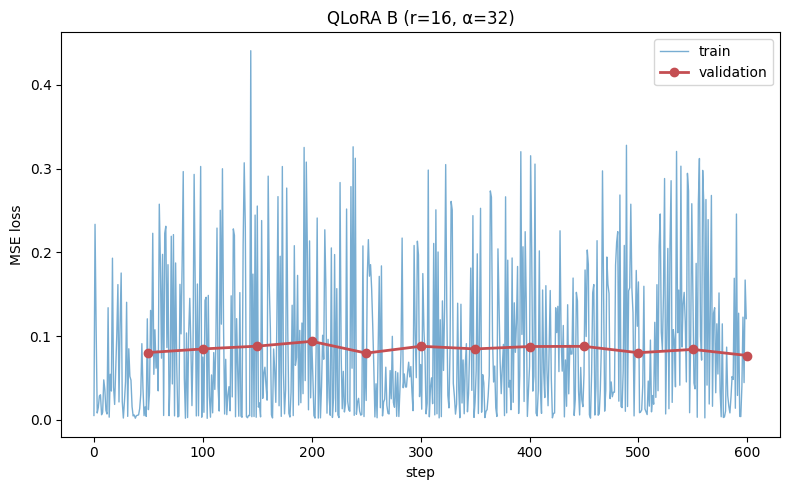

In [15]:
full_result = train_qlora(
    winner_cfg, full_train_dataloader, cfg.n_full_steps, cfg.full_eval_every, cfg.full_output_root
)

qlora_best_path = full_result["save_path"]
print(f"\nQLoRA best checkpoint: {full_result['name']} (val loss {full_result['final_val_loss']:.4f})")
print(f"Weights saved to: {qlora_best_path}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(full_result["train_losses"], label="train", alpha=0.6, linewidth=1)
ax.plot(full_result["val_steps"], full_result["val_losses"], label="validation", marker="o", linewidth=2, color="#C44E52")
ax.set_title(full_result["name"]); ax.set_xlabel("step"); ax.set_ylabel("MSE loss"); ax.legend()
plt.tight_layout(); plt.savefig("qlora_training_curve.png", dpi=140, bbox_inches="tight"); plt.show()


## 5. Package for submission / comparison against LoRA/DoRA

In [16]:
import shutil
shutil.make_archive("qlora_full_runs", "zip", cfg.full_output_root)
print(f"Zipped {cfg.full_output_root} -> qlora_full_runs.zip")
print(f"\nTo compare against your existing LoRA/DoRA results, point inference.ipynb's")
print(f"LORA_PATH at '{qlora_best_path}' and re-run, or add this checkpoint as a third")
print(f"row in your results table alongside the LoRA/DoRA numbers you already have.")

try:
    from google.colab import files
    files.download("qlora_full_runs.zip")
except ImportError:
    pass


Zipped qlora_full_runs -> qlora_full_runs.zip

To compare against your existing LoRA/DoRA results, point inference.ipynb's
LORA_PATH at 'qlora_full_runs/QLoRA_B_r16_α32' and re-run, or add this checkpoint as a third
row in your results table alongside the LoRA/DoRA numbers you already have.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>